In [1]:
# Import the FEMSystem Class from directory above
import sys
from VisualizeVF import VisualizeVF
sys.path.append('..')
from FEMSystem import FEMSystem
from RabiLondonSystem import RabiLondonSystem

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np
from Units2D import Units2D
from skfem import Basis, ElementTetP1, BilinearForm, LinearForm, asm
from skfem.helpers import curl
from scipy.sparse.linalg import spsolve
from matplotlib.tri import Triangulation


Effective mass: 4.509837029339474e-34 kg | 0.00024779324337030075 times (2m_e)


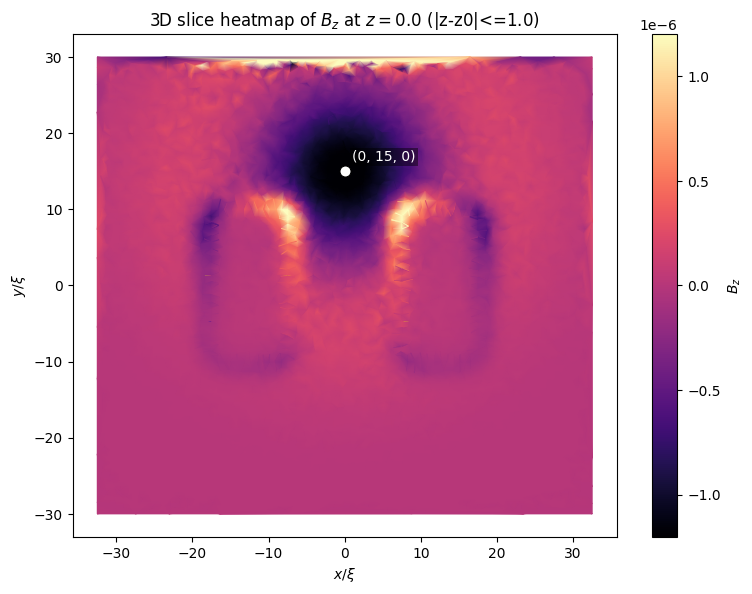

Source is: m = 1 | sigma: 15 | Coordinate: (0, 15, 0)
DOFS: (3, 189951)
Params:
  sidelenX: 10.0
  sidelenY: 20.0
  sidelenZ: 20.0
  padding: 20.0
  separation: 15.0
  material: 0.0033784
  mesh_x_min: -32.5
  mesh_x_max: 32.5
  mesh_x_span: 65.0
  mesh_y_min: -30.0
  mesh_y_max: 30.0
  mesh_y_span: 60.0
  mesh_z_min: -30.0
  mesh_z_max: 30.0
  mesh_z_span: 60.0


In [ ]:

# import pickled object
class _CompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        # Older checkpoints store RabiLondon2D as __main__.RabiLondon2D.
        # Remap to the current implementation class.
        if module == "__main__" and name == "RabiLondon2D":
            return RabiLondonSystem
        return super().find_class(module, name)


with open('allplots/fig1-2.pkl', 'rb') as f:
    pickle_obj = _CompatUnpickler(f).load()
    rabilondon = pickle_obj["rabilondon"]
    A_sol = pickle_obj["A_sol"]
    basis_edge = pickle_obj["basis_edge"]
    source_obj = pickle_obj["source_obj"]
    omega_d_rad_s = pickle_obj["omega_d_rad_s"]
    c_bar = pickle_obj["c_bar"]
    hamiltonian_time_data = pickle_obj["hamiltonian_time_data"]
    kappa = pickle_obj["kappa"]
    if "xi" in pickle_obj:
        xi = pickle_obj["xi"]
    else:
        xi = .39e-10 * 1

units2d = Units2D(xi,kappa)

# Visualize Solution
vis = VisualizeVF(rabilondon.mesh, basis_edge, A_sol)
source_xy = source_obj['source_coord'][0:2]
vis.visualize_bz_slice_z0_3d(z0=0.0, tol=1.0, bz_symmetric_percentile=99.0, cmap="magma",source_xy=source_xy)

omega_d_nondim = units2d.convert_rad_s_to_energy(omega_d_rad_s,xi)
omega_q_nondim = rabilondon.omega_q

print(f"Source is: m = {source_obj['m']} | sigma: {source_obj['sigma']} | Coordinate: {source_obj['source_coord']}")

params = pickle_obj.get("parameters", {})
femsystem = rabilondon.femsystem
coords = np.asarray(femsystem.doflocs)
mins = coords.min(axis=1)
maxs = coords.max(axis=1)
spans = maxs - mins

print(f"DOFS: {femsystem.doflocs.shape}")

print("Params:")
# 1) Raw checkpoint parameters (authoritative if present)
for k in ["sidelenX", "sidelenY", "sidelenZ", "padding", "separation", "material", "N"]:
    if k in params:
        print(f"  {k}: {params[k]}")

for k in sorted(params):
    if k not in {"sidelenX", "sidelenY", "sidelenZ", "padding", "separation", "material", "N"} and any(
        tag in k.lower() for tag in ["side", "pad", "sep", "width", "height", "length", "radius", "thick", "gap", "domain"]
    ):
        print(f"  {k}: {params[k]}")

# 2) Geometry computed directly from FEM mesh dof coordinates
axis_names = ["x", "y", "z"][:coords.shape[0]]
for i, axis in enumerate(axis_names):
    print(f"  mesh_{axis}_min: {mins[i]}")
    print(f"  mesh_{axis}_max: {maxs[i]}")
    print(f"  mesh_{axis}_span: {spans[i]}")

# Construct Rabi Hamiltonian

In [3]:
# Import A1 and A2 Matrices from pickle, and Pauli Decompose TLS Matrices
A1_mat, A2_mat = hamiltonian_time_data["A1_mat"], hamiltonian_time_data["A2_mat"]
A1_mat_TLS, A2_mat_TLS= rabilondon.TLS_matrix(A1_mat), rabilondon.TLS_matrix(A2_mat)
A1_mat_TLS_decomposed, A2_mat_TLS_decomposed = rabilondon.pauli_decompose(A1_mat_TLS), rabilondon.pauli_decompose(A2_mat_TLS)

print(f"A1I: {A1_mat_TLS_decomposed[0]} | A1X: {A1_mat_TLS_decomposed[1]} | A1Y: {A1_mat_TLS_decomposed[2]} | A1Z: {A1_mat_TLS_decomposed[3]}")
print(f"A2I: {A2_mat_TLS_decomposed[0]} | A2X: {A2_mat_TLS_decomposed[1]} | A2Y: {A2_mat_TLS_decomposed[2]} | A2Z: {A2_mat_TLS_decomposed[3]}")

a1_off_diag_max, a2_off_diag_max = np.max(np.abs(A1_mat_TLS - np.diag(np.diag(A1_mat_TLS)))), np.max(np.abs(A2_mat_TLS - np.diag(np.diag(A2_mat_TLS))))     
detuning_max = max(np.abs(A1_mat_TLS_decomposed[3]), np.abs(A2_mat_TLS_decomposed[3]))
a1z_detuning = np.real(A1_mat_TLS_decomposed[3])
a2z_detuning = np.real(A2_mat_TLS_decomposed[3])
print(f"A1 Off Diagonal Max: {a1_off_diag_max}")
print(f"A2 Off Diagonal Max: {a2_off_diag_max}\n")
print(f"Check that A1 off diagonal max is much much larger for Rabi Oscillations!! It is {a1_off_diag_max/a2_off_diag_max} times larger.")
print(f"Check that detuning is much lower too! Off diagonal of A1 is {a1_off_diag_max/a2z_detuning} times larger than the detuning (A1z and A2z).\n\n")

# In units of NON-DIMENSIONAL ENERGY
rabi_freq = np.sqrt(np.abs(A1_mat_TLS_decomposed[1])**2 + np.abs(A1_mat_TLS_decomposed[2])**2)  

# In units of RAD/S. Remember, energy nondim units are the SAME in 2D and 3D (so go from nondim energy to real energy, then just divide by hbar to go from real energy to rad/s)
rabi_freq_rad_s = units2d.convert_energy_to_rad_s(rabi_freq,xi)
omega_d_rad_s = units2d.convert_energy_to_rad_s(omega_d_nondim,xi)

print(f"Rabi Frequency (in nondim units): {rabi_freq} | (in rad/s):{rabi_freq_rad_s} or {(rabi_freq_rad_s/(2*np.pi*1e9))} GHz")
print(f"Drive Frequency (in nondim units): {omega_d_nondim} | (in rad/s):{omega_d_rad_s} or {(omega_d_rad_s/(2*np.pi*1e9))} GHz")

rabi_period = float(2*np.pi/rabi_freq_rad_s)
drive_period = float(2*np.pi/omega_d_rad_s) # Remember Hamiltonian is nondimmed, so 1/energy or 1/time is nondimmed
print(f"Rabi Period: {rabi_period} s")
print(f"Drive Period: {drive_period} s")
print(f"********* Ratio: {rabi_period/drive_period} *********\n\n")

print(f"A1Z Detuning: {a1z_detuning} | A2Z Detuning: {a2z_detuning} | Need to be negligible compared to qubit frequncy: {omega_d_nondim}")
print(f"Fixing Drive Frequency by Adding Detuning")

# NEW DRIVE FREQUENCY ( + Detuning)
omega_d_nondim_new = (omega_d_nondim + 2*a2z_detuning)
drive_period_new = float(2*np.pi/omega_d_nondim_new)

A1I: -1.425750076666774e-16j | A1X: 0j | A1Y: (-6.748427594516215e-09+0j) | A1Z: -3.685630935916593e-17j
A2I: (2.7120302531491447e-11+0j) | A2X: (2.556737373898832e-13+0j) | A2Y: -8.131516293641283e-20j | A2Z: (7.311512506547047e-14+0j)
A1 Off Diagonal Max: 6.748427594516215e-09
A2 Off Diagonal Max: 2.5567381870504613e-13

Check that A1 off diagonal max is much much larger for Rabi Oscillations!! It is 26394.67578125 times larger.
Check that detuning is much lower too! Off diagonal of A1 is 92298.65625 times larger than the detuning (A1z and A2z).


Rabi Frequency (in nondim units): 6.748427594516215e-09 | (in rad/s):129687672833.0184 or 20.640434189459384 GHz
Drive Frequency (in nondim units): 1.248730182647705 | (in rad/s):2.399742889966362e+19 or 3819309430.8777676 GHz
Rabi Period: 4.8448593223425406e-11 s
Drive Period: 2.618274371579724e-19 s
********* Ratio: 185040169.01098937 *********


A1Z Detuning: 0.0 | A2Z Detuning: 7.311512506547047e-14 | Need to be negligible compared to q

A1_TLS_x: 0j | A1_TLS_y: (-6.748427594516215e-09+0j) | detuning: -1.2487301859209765e-08
Rabi Frequency (in nondim units): 1.4194153140644843e-08 | (in rad/s):272775644824.51468 or 43.41359222890069 GHz
Rabi Magnitude: 0.22604047874082686
A1_TLS_x: 0j | A1_TLS_y: (-6.748427594516215e-09+0j) | detuning: -1.1846927439052024e-08
Rabi Frequency (in nondim units): 1.3634183708723378e-08 | (in rad/s):262014451721.91187 or 41.70089515305504 GHz
Rabi Magnitude: 0.24498918254725377
A1_TLS_x: 0j | A1_TLS_y: (-6.748427594516215e-09+0j) | detuning: -1.1206552796849678e-08
Rabi Frequency (in nondim units): 1.3081593987188012e-08 | (in rad/s):251395077947.25635 or 40.01076932427818 GHz
Rabi Magnitude: 0.2661238880438768
A1_TLS_x: 0j | A1_TLS_y: (-6.748427594516215e-09+0j) | detuning: -1.0566178376691937e-08
Rabi Frequency (in nondim units): 1.2537360214380316e-08 | (in rad/s):240936284326.9591 or 38.34620062082989 GHz
Rabi Magnitude: 0.28972967798076077
A1_TLS_x: 0j | A1_TLS_y: (-6.748427594516215e-

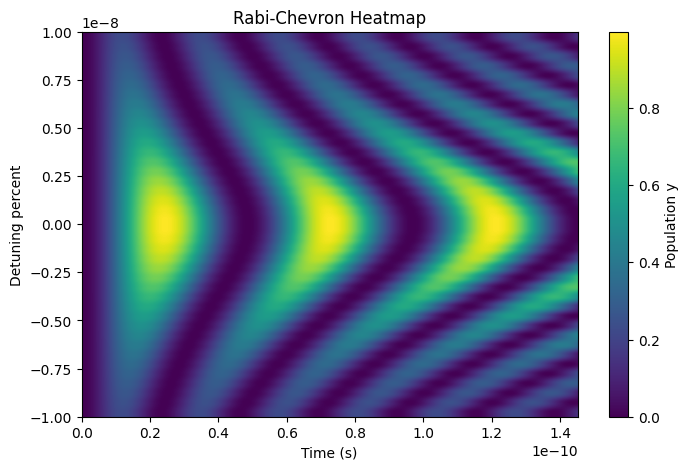

In [19]:
## Rabi Oscillation parameters


highest_detuning_percent = 0.00000001
steps = np.linspace(-highest_detuning_percent,highest_detuning_percent,40)

max_rabi_period = 0
rabi_magnitudes = np.zeros_like(steps)
rabi_freqs = np.zeros_like(steps)

for i,step in enumerate(steps):

    manual_detuning_percent = step
    A1_TLS_x, A1_TLS_y = A1_mat_TLS_decomposed[1], A1_mat_TLS_decomposed[2]
    detuning = omega_d_nondim * (1 + manual_detuning_percent) - omega_q_nondim
    print(f"A1_TLS_x: {A1_TLS_x} | A1_TLS_y: {A1_TLS_y} | detuning: {detuning}")

    rabi_magnitude = (np.abs(A1_TLS_x)**2 + np.abs(A1_TLS_y)**2) / (np.abs(A1_TLS_x)**2 + np.abs(A1_TLS_y)**2 + detuning**2)
    rabi_freq_nondim = np.sqrt(np.abs(A1_TLS_x)**2 + np.abs(A1_TLS_y)**2 + detuning**2)
    rabi_freq_rad_s = units2d.convert_energy_to_rad_s(rabi_freq_nondim,xi)
    rabi_period = float(2*np.pi/rabi_freq_rad_s)

    print(f"Rabi Frequency (in nondim units): {rabi_freq_nondim} | (in rad/s):{rabi_freq_rad_s} or {(rabi_freq_rad_s/(2*np.pi*1e9))} GHz")
    print(f"Rabi Magnitude: {rabi_magnitude}")

    # Plot (magnitude) * (1 - cos(rabi_freq_rad_s * t)/2)
    max_rabi_period = max(max_rabi_period,rabi_period)
    rabi_magnitudes[i] = np.real(rabi_magnitude)
    rabi_freqs[i] = np.real(rabi_freq_rad_s)



# y = rabi_magnitude * (1 - np.cos(rabi_freq_rad_s * t_plot))/2


t_heatmap = np.linspace(0, 3 * max_rabi_period, 500)

# Ensure real-valued arrays in case upstream quantities carry tiny imaginary parts
rabi_magnitudes_real = np.real(rabi_magnitudes)
rabi_freqs_real = np.real(rabi_freqs)
detuning_axis = np.real(steps)

# population_map[i, j] = population at detuning i and time j
population_map = np.array([
    mag * (1 - np.cos(freq * t_heatmap)) / 2
    for mag, freq in zip(rabi_magnitudes_real, rabi_freqs_real)
])
plt.figure(figsize=(8, 5))
plt.imshow(
    population_map,
    aspect='auto',
    origin='lower',
    extent=[t_heatmap[0], t_heatmap[-1], detuning_axis[0], detuning_axis[-1]],
    cmap='viridis'
)
plt.colorbar(label='Population y')
plt.xlabel('Time (s)')
plt.ylabel('Detuning percent')
plt.title('Rabi-Chevron Heatmap')
plt.show()
# plt.plot(t_plot,y)
# plt.xlabel("Time (s)")
# plt.ylabel("Population")
# plt.title("Rabi Oscillations")
# plt.show()

Time evolution:   0%|          | 0/399 [00:00<?, ?it/s]

Delta_eff = 0.0
Omega_eff = 6.748427594516215e-09, |Delta|/Omega = 0.0
[0.00000000e+00 6.98293720e+05 1.39658744e+06 ... 2.79177829e+09
 2.79247659e+09 2.79317488e+09] [0.00000000e+00 5.55163170e-06 2.22064035e-05 ... 2.22907270e-05
 5.59383387e-06 7.99006712e-11]
[[ 0.00000000e+00+0.00000000e+00j  1.00000000e+00+0.00000000e+00j]
 [-7.49457572e-12-2.35619008e-03j  9.99997224e-01+5.10679558e-08j]
 [-1.48893571e-11-4.71236708e-03j  9.99988897e-01+1.02135592e-07j]
 ...
 [-3.04302584e-08-4.72130565e-03j -9.99988855e-01+1.74426320e-08j]
 [-3.06224889e-08-2.36512872e-03j -9.99997203e-01-3.35532115e-08j]
 [-3.08146492e-08-8.93866442e-06j -1.00000000e+00-8.45488335e-08j]]


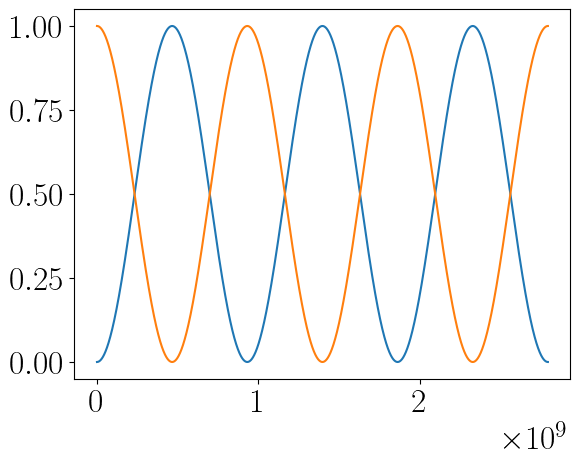

In [ ]:
# Construct TLS Hamiltonian in Interaction Picture (rotated at DRIVE frequency, not typical H0)
H_tls_interaction = rabilondon.rabi_hamiltonian_tls_interaction_picture(basis_edge,A_sol,omega_d_nondim_new,A1_mat_TLS_decomposed,A2_mat_TLS_decomposed)

# Evolve for Rabi Oscillations
states, t_strob = rabilondon.rabi_efficient(H_tls_interaction,drive_period_new,400,rabi_period*3,4000)

print(f"Delta_eff = {np.real((rabilondon.eigenvalues[1] - rabilondon.eigenvalues[0]) - omega_d_nondim_new)}")
print(f"Omega_eff = {np.sqrt(np.abs(A1_mat_TLS_decomposed[1])**2 + np.abs(A1_mat_TLS_decomposed[2])**2)}, |Delta|/Omega = {np.abs(np.real((rabilondon.eigenvalues[1] - rabilondon.eigenvalues[0]) - omega_d_nondim_new)) / max(np.abs(np.sqrt(np.abs(A1_mat_TLS_decomposed[1])**2 + np.abs(A1_mat_TLS_decomposed[2])**2)), 1e-30)}")

# Plot
pop0, pop1 = np.abs(states[:, 0])**2, np.abs(states[:, 1])**2
plt.plot(t_strob, pop0)
plt.plot(t_strob, pop1)
print(t_strob,pop0)
print(states)

## Generate the Figure

Fitted omega: 6.74842759e-09
Omega std err: 3.58e-17
RMSE: 7.71e-08


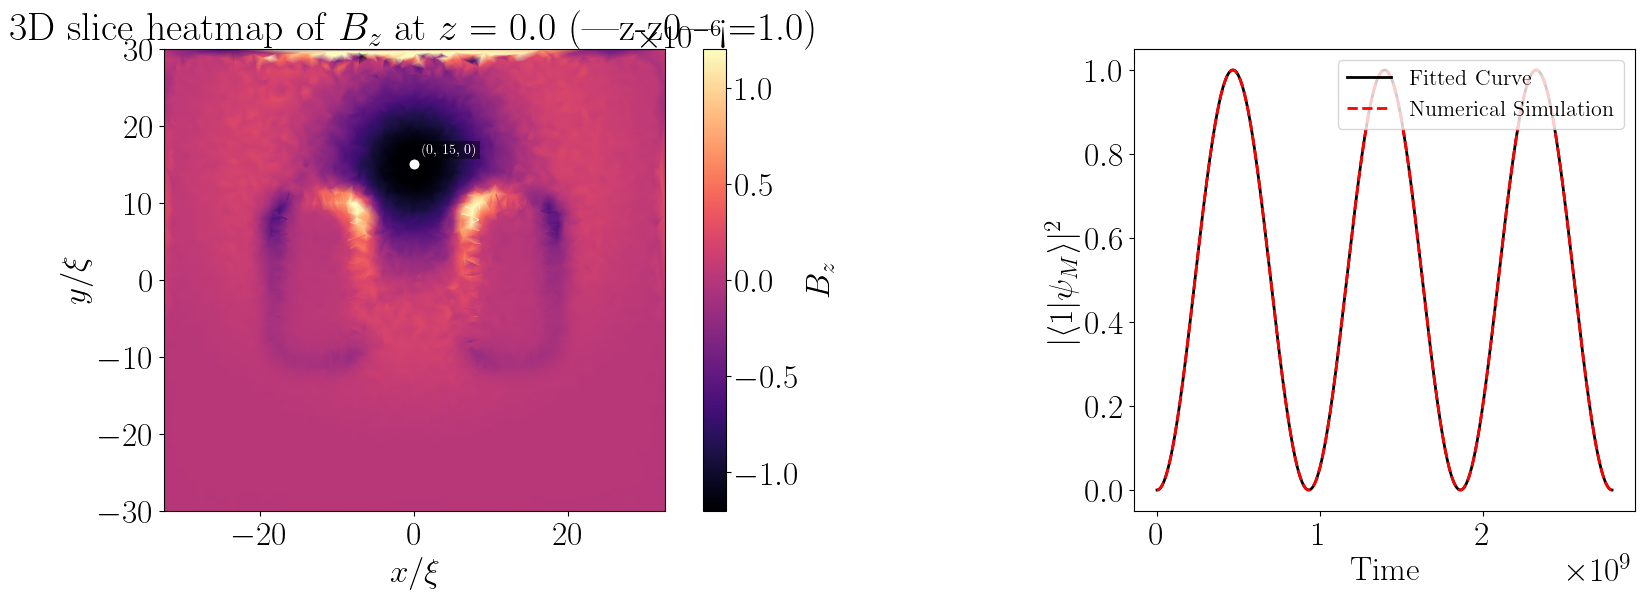

'\nPlot 3: 1D London fit of panel-2 cross section\n'

In [35]:
from scipy.optimize import curve_fit

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 24,
})

# Create a 2D slice from the 3D mesh using basis_edge quadrature (robust to nq=14)
z_cut, z_tol = 0.0, 2.0
basis_p1_3d = Basis(rabilondon.mesh, ElementTetP1(), quadrature=basis_edge.quadrature)

@BilinearForm
def mass_matrix_scalar(u, v, w):
    return u * v

@LinearForm
def rhs_bz(v, w):
    return curl(w["A_edge"])[2] * v

M_s = asm(mass_matrix_scalar, basis_p1_3d)
b_s = asm(rhs_bz, basis_p1_3d, A_edge=basis_edge.interpolate(A_sol))
Bz_nodes = np.asarray(spsolve(M_s, b_s)).ravel()

x_all = np.asarray(basis_p1_3d.doflocs[0]).ravel()
y_all = np.asarray(basis_p1_3d.doflocs[1]).ravel()
z_all = np.asarray(basis_p1_3d.doflocs[2]).ravel()

slice_mask = np.abs(z_all - z_cut) <= z_tol
if np.count_nonzero(slice_mask) < 3:
    raise ValueError(f"Slice has too few points at z={z_cut} with tol={z_tol}; increase z_tol.")

x_slice = x_all[slice_mask]
y_slice = y_all[slice_mask]
bz_slice = Bz_nodes[slice_mask]

# Create three plots side-by-side with dynamic middle-column width
x_span = float(np.max(x_slice) - np.min(x_slice))
y_span = float(np.max(y_slice) - np.min(y_slice))
mid_ratio = float(np.clip((x_span / y_span) if y_span > 0 else 1.0, 0.7, 2.0))

fig = plt.figure(figsize=(22, 6), constrained_layout=False)
gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.0], wspace=0.25)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
# ax3 = fig.add_subplot(gs[0, 2])

'''
Plot 1: 2D cross section (3D geometry)
'''
# tri2d = Triangulation(x_slice, y_slice)
# kw = dict(shading="gouraud", cmap="magma")
# lim = np.percentile(np.abs(bz_slice), 99.0)
# if lim > 0:
#     kw["vmin"], kw["vmax"] = -float(lim), float(lim)    
# tpc = ax2.tripcolor(tri2d, bz_slice, **kw)
vis.visualize_bz_slice_z0_3d(z0=0.0, tol=1.0, bz_symmetric_percentile=99.0, cmap="magma",source_xy=source_xy,ax=ax1,show=False)
# plt.colorbar(tpc, ax=ax2, label="$B_z$ $[B_0]$", fraction=0.046, pad=0.04)
ax1.set_xlim(np.min(x_slice), np.max(x_slice))
ax1.set_ylim(np.min(y_slice), np.max(y_slice))
if x_span > 0 and y_span > 0:
    ax2.set_box_aspect(y_span / x_span)
ax1.set_aspect("equal", adjustable="box")
ax1.set_xlabel(r"$x/\xi$")
ax1.set_ylabel(r"$y/\xi$")

'''
Plot 2: Rabi Oscillations (efficient method)
'''
# Use the already computed efficient dynamics from the previous cell.
sample_t = np.asarray(t_strob, dtype=float)

def rabi_model(t, omega):
    return 0.5 * (1.0 - np.cos(omega * t))


omega0 = float(np.real(rabi_freq)) if np.ndim(rabi_freq) == 0 else float(np.real(rabi_freq[0]))

try:
    popt, pcov = curve_fit(
        rabi_model,
        sample_t,
        pop0,
        p0=[max(omega0, 1e-15)],
        bounds=(0.0, np.inf),
    )
    omega_fit = float(popt[0])
    omega_fit_std = float(np.sqrt(np.diag(pcov))[0]) if np.isfinite(pcov).all() else np.nan
    fit_vals = rabi_model(sample_t, omega_fit)
    rmse = float(np.sqrt(np.mean((pop0 - fit_vals) ** 2)))

    print(f"Fitted omega: {omega_fit:.9g}")
    print(f"Omega std err: {omega_fit_std:.3g}")
    print(f"RMSE: {rmse:.3g}")
except Exception as e:
    omega_fit = np.nan
    fit_vals = np.full_like(sample_t, np.nan)
    print("Fit failed:", e)

if np.isfinite(omega_fit):
    fit_vals = rabi_model(sample_t, float(np.real(omega_fit)))
    ax2.plot(sample_t, fit_vals, "-", color="black", lw=2, label="Fitted Curve")


ax2.plot(sample_t, pop0, "--", color="red", lw=2, label="Numerical Simulation")
# if np.isfinite(omega_fit):
#     ax1.plot(sample_t, fit_vals, "--", lw=2, color="red", label="Fitted Curve")

ax2.set_xlabel("Time")
ax2.set_ylabel(r"$|\langle 1 | \psi_M \rangle|^2$")
ax2.legend(loc="upper right", fontsize=16)

plt.show()
'''
Plot 3: 1D London fit of panel-2 cross section
'''
# y_cut, y_tol = 0.0, 2.0
# line_mask = np.isclose(y_slice, y_cut, atol=y_tol)
# if np.count_nonzero(line_mask) < 4:
#     y_band = max(np.percentile(np.abs(y_slice - y_cut), 8), 1e-9)
#     line_mask = np.abs(y_slice - y_cut) <= y_band

# x_line = np.asarray(x_slice[line_mask]).ravel()
# bz_line = np.asarray(bz_slice[line_mask]).ravel()

# order = np.argsort(x_line)
# x_line = x_line[order]
# bz_line = bz_line[order]

# xmin, xmax = -15,-10
# fit_mask = (x_line >= xmin) & (x_line <= xmax)

# print(len(fit_mask))

# if np.count_nonzero(fit_mask) < 4:
#     fit_mask = np.ones_like(x_line, dtype=bool)

# x_fit_data = x_line[fit_mask]
# bz_fit_data = bz_line[fit_mask]

# x0 = float(np.min(x_fit_data))

# def exp_decay_shifted(x, A, tau, C):
#     return A * np.exp(-(x - x0) / tau) + C

# A0 = float(np.max(bz_fit_data) - np.min(bz_fit_data))
# tau0 = float(max((np.max(x_fit_data) - np.min(x_fit_data)) / 2.0, 1e-9))
# C0 = float(np.min(bz_fit_data))

# popt, pcov = curve_fit(
#     exp_decay_shifted,
#     x_fit_data,
#     bz_fit_data,
#     p0=[A0, tau0, C0],
#     bounds=([-np.inf, 1e-12, -np.inf], [np.inf, np.inf, np.inf]),
# )
# A_opt, tau_opt, C_opt = [float(v) for v in popt]
# tau_std = float(np.sqrt(np.diag(pcov))[1]) if np.isfinite(pcov).all() else np.nan
# print(
#     f"London fit (from 2D section): A={A_opt:.3g}, tau={tau_opt:.3g}, C={C_opt:.3g}, tau_std={tau_std:.3g}"
# )

# ax3.plot(x_fit_data, bz_fit_data, "o", color="black", ms=4, lw=1.5)
# x_dense = np.linspace(float(np.min(x_fit_data)), float(np.max(x_fit_data)), 200)
# ax3.plot(x_dense, exp_decay_shifted(x_dense, *popt), "r--", lw=2)
# ax3.axhline(0.0, color="gray", linestyle="--", lw=1)
# ax3.set_xlabel(r"$x/\xi$")
# ax3.set_ylabel(r"$B_z$ $[B_0]$")
# ax3.grid(alpha=0.3)

# # Avoid collision with panel-2 colorbar text.
# ax3.yaxis.set_label_position("right")
# ax3.yaxis.tick_right()
# ax3.tick_params(axis="y", pad=4)

# # Panel labels
# for ax, lab in zip([ax1, ax2, ax3], ["(a)", "(b)", "(c)"]):
#     ax.text(
#         0.02, 0.98, lab,
#         transform=ax.transAxes,
#         ha="left", va="top",
#         fontweight="bold",
#         fontsize=32,
#         bbox=dict(facecolor="white", edgecolor="none", alpha=0.65, pad=1.2),
#     )

# fig.subplots_adjust(left=0.05, right=0.98, bottom=0.18, top=0.95, wspace=0.12)

In [ ]:
# Heatmap of Rabi population vs time and detuning

t_heatmap = np.linspace(0, 3 * max_rabi_period, 500)

# Ensure real-valued arrays in case upstream quantities carry tiny imaginary parts
rabi_magnitudes_real = np.real(rabi_magnitudes)
rabi_freqs_real = np.real(rabi_freqs)
detuning_axis = np.real(steps)

# population_map[i, j] = population at detuning i and time j
population_map = np.array([
    mag * (1 - np.cos(freq * t_heatmap)) / 2
    for mag, freq in zip(rabi_magnitudes_real, rabi_freqs_real)
])

plt.figure(figsize=(8, 5))
plt.imshow(
    population_map,
    aspect='auto',
    origin='lower',
    extent=[t_heatmap[0], t_heatmap[-1], detuning_axis[0], detuning_axis[-1]],
    cmap='viridis'
)
plt.colorbar(label='Population y')
plt.xlabel('Time (s)')
plt.ylabel('Detuning percent')
plt.title('Rabi Population Heatmap')
plt.show()